# **Classification Project : Credit Risk Analysis**

In [149]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Credit_Risk_Analysis_Dataset_Regression_Anu.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


**Display Basic Info**

In [150]:
df.shape
print("No of rows :",df.shape[0])
print("No of columns :",df.shape[1])

No of rows : 32581
No of columns : 12


In [151]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [152]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [153]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [155]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [156]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**Missing Value Handling**

Check Missing Value

In [157]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [158]:
df=df.drop('person_age',axis=1)
df

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Fillna()

In [159]:
df['person_emp_length']=df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate']=df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [160]:
df[['person_emp_length','loan_int_rate']].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


**Data Processing**

Encoding
Handling Categorical Data

In [161]:
intent_map={'PERSONAL':0,'EDUCATION':1,'VENTURE':2,'MEDICAL':3,'DEBTCONSOLIDATION':4,'HOMEIMPROVEMENT':5}
df['loan_intent']=df['loan_intent'].map(intent_map)

In [162]:
grade_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
df['loan_grade']=df['loan_grade'].map(grade_map)

In [163]:
home_map={"RENT":0,"OWN":1,"MORTGAGE":2,"OTHER":3}
df['person_home_ownership']=df['person_home_ownership'].map(home_map)

In [164]:
df['cb_person_default_on_file']=df['cb_person_default_on_file'].map({'Y':1,'N':0})

In [165]:
df['loan_intent'].value_counts()

,count
loan_intent,
1,6453
3,6071
2,5719
0,5521
4,5212
5,3605


In [166]:
df['person_home_ownership'].value_counts()

,count
person_home_ownership,
0,16446
2,13444
1,2584
3,107


In [167]:
df['loan_grade'].value_counts()

,count
loan_grade,
1,10777
2,10451
3,6458
4,3626
5,964
6,241
7,64


In [168]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
0,26836
1,5745


**Seperate Feature And Target**

In [169]:
x=df.drop("loan_status",axis=1)
x

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,59000,0,123.0,0,4,35000,16.02,0.59,1,3
1,9600,1,5.0,1,2,1000,11.14,0.10,0,2
2,9600,2,1.0,3,3,5500,12.87,0.57,0,3
3,65500,0,4.0,3,3,35000,15.23,0.53,0,2
4,54400,0,8.0,3,3,35000,14.27,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...
32576,53000,2,1.0,0,3,5800,13.16,0.11,0,30
32577,120000,2,4.0,0,1,17625,7.49,0.15,0,19
32578,76000,0,3.0,5,2,35000,10.99,0.46,0,28
32579,150000,2,5.0,0,2,15000,11.48,0.10,0,26


In [170]:
y=df['loan_status']
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
32576,0
32577,0
32578,1
32579,0


**Split The Data 80% And 20%**

In [171]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Feature Scaling**


Scaling

In [172]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [173]:
x_test

array([[-0.68465096,  0.08982244,  0.28987743, ...,  1.80079234,
        -0.47385615, -0.92530173],
       [-0.03064606, -0.94991617, -1.13301827, ..., -0.08717016,
         2.11034511,  1.0464767 ],
       [ 0.11468836,  1.12956105,  1.23847456, ...,  0.47921859,
        -0.47385615, -0.67882943],
       ...,
       [ 0.87769408,  1.12956105, -0.18442114, ..., -0.74795703,
        -0.47385615, -0.92530173],
       [ 0.62335884,  1.12956105, -0.89586899, ..., -1.03115141,
        -0.47385615, -0.67882943],
       [ 0.11468836,  0.08982244,  0.28987743, ...,  1.70639422,
        -0.47385615,  0.55353209]])

**Model Creation**


TRain All Clasification Models

In [174]:
from sklearn.linear_model import LogisticRegression
l_model=LogisticRegression()


In [175]:
from sklearn.naive_bayes import GaussianNB
n_model=GaussianNB()


In [176]:
from sklearn.svm import SVC
s_model=SVC()

In [177]:
from sklearn.ensemble import RandomForestClassifier
r_model=RandomForestClassifier(n_estimators=150,random_state=42)

In [178]:
from sklearn.neighbors import KNeighborsClassifier
k_model=KNeighborsClassifier(n_neighbors=5)

In [179]:
models=[l_model,n_model,s_model,k_model,r_model]


**Perfomance Evaluation**

In [199]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Accuracy score All Models

In [200]:
model_name=[]
accuracy_scores=[]
for model in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  score=accuracy_score(y_test,y_pred)
  print(model,"Accuracy Score :",score)
  print("-"*50)
  model_name.append(model.__class__.__name__)
  accuracy_scores.append(score)

LogisticRegression() Accuracy Score : 0.8396501457725948
--------------------------------------------------
GaussianNB() Accuracy Score : 0.8005217124443762
--------------------------------------------------
SVC() Accuracy Score : 0.8988798526929569
--------------------------------------------------
KNeighborsClassifier() Accuracy Score : 0.8922817247199631
--------------------------------------------------
RandomForestClassifier(n_estimators=150, random_state=42) Accuracy Score : 0.9094675464170631
--------------------------------------------------


Plot Bar Chart

In [202]:
plt.bar(model_name,accuracy_scores)
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Comparison - Accuracy")
plt.xticks(rotation=45)
plt.show()

Model Creation

In [186]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=150,random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [187]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [188]:
ap=pd.DataFrame({"Actual Value ":y_test,"Predicted Value ":y_pred})
ap

,Actual Value,Predicted Value
14668,0,0
24614,0,0
11096,0,0
10424,1,1
26007,1,1
...,...,...
31330,0,0
2862,0,0
14754,0,0
14170,0,0


In [189]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9094675464170631

In [190]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[4881,  191],
       [ 399, 1046]])

In [191]:
y_pred=model.predict([[9600	,1,	5.0	,1,	2	,1000	,11.14	,0.10	,0,2]])
y_pred

array([1])

In [192]:
y_pred=model.predict([[54400,0	,8.0,	3,3,35000	,14.27,0.55,1,4]])
y_pred

array([0])

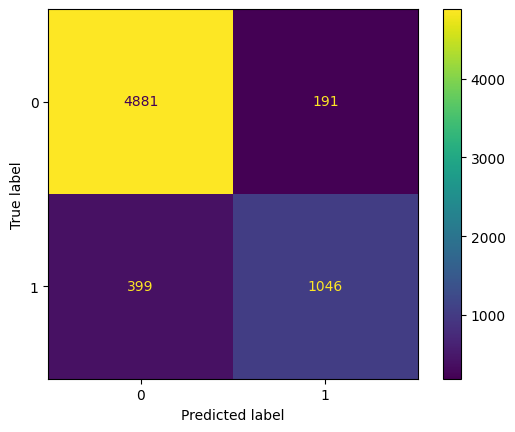

In [193]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Bar Plot For Categorical Columns

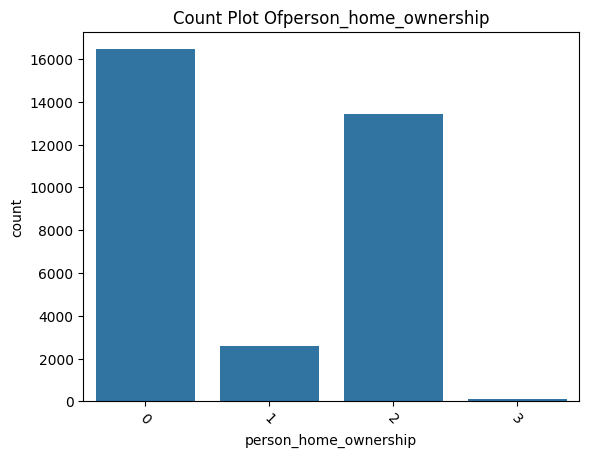

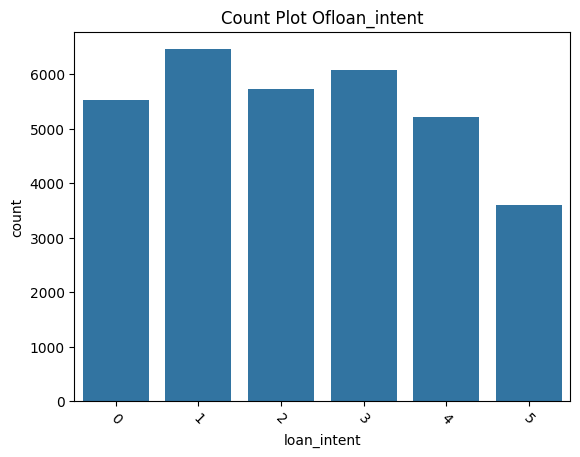

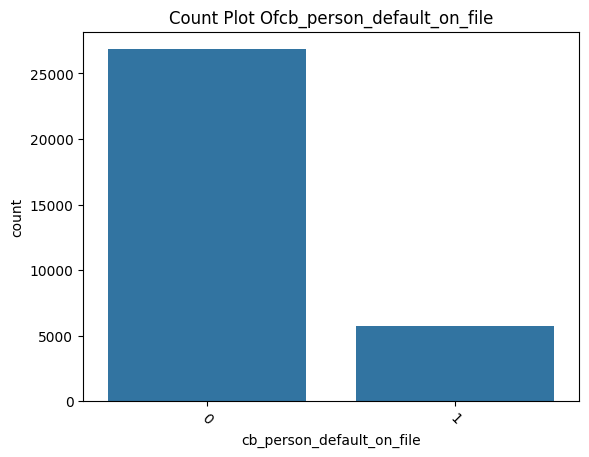

In [194]:
categorical_col=["person_home_ownership","loan_intent","cb_person_default_on_file"]
for col in categorical_col:
  sns.countplot(x=df[col])
  plt.title("Count Plot Of"+col)
  plt.xticks(rotation=-45)
  plt.show()

Count Of safe Vs Risky Loans

In [204]:
df['loan_status'].value_counts().plot(kind='bar')
plt.xlabel("Loan Status (0 = Safe, 1 = Risky)")
plt.ylabel("Count")
plt.title("Loan Status Distrubution")
plt.show()

Count For Average Loan Amount

In [205]:
plt.figure(figsize=(6,4))
df.groupby('loan_status')['loan_amnt'].mean().plot(kind='bar')
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")
plt.title("Average Loan Amount For Safe Vs Risky Borrowers")
plt.show()

Histogram For Numerical Columns

In [206]:
import matplotlib.pyplot as plt

numerical_cols=["person_income","person_emp_length","loan_amnt","loan_int_rate","loan_status","loan_percent_income","cb_person_cred_hist_length"]

for col in numerical_cols:
  plt.figure(figsize=(8,5))
  plt.hist(df[col].dropna(),bins=30)
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.title("Histogram of"+col)
  plt.legend()
  plt.show()